In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Data/train.csv')

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Why do EDA

- Model building
- Analysis and reporting
- Validate assumptions
- Handling missing values
- feature engineering
- detecting outliers

In [4]:
# Remember it is an iterative process

### Column Types

- **Numerical** - Age,Fare,PassengerId
- **Categorical** - Survived, Pclass, Sex, SibSp, Parch,Embarked
- **Mixed** - Name, Ticket, Cabin

### Univariate Analysis

Univariate analysis focuses on analyzing each feature in the dataset independently.

- **Distribution analysis**: The distribution of each feature is examined to identify its shape, central tendency, and dispersion.

- **Identifying potential issues**: Univariate analysis helps in identifying potential problems with the data such as outliers, skewness, and missing values

#### The shape of a data distribution refers to its overall pattern or form as it is represented on a graph. Some common shapes of data distributions include:

- **Normal Distribution**: A symmetrical and bell-shaped distribution where the mean, median, and mode are equal and the majority of the data falls in the middle of the distribution with gradually decreasing frequencies towards the tails.

- **Skewed Distribution**: A distribution that is not symmetrical, with one tail being longer than the other. It can be either positively skewed (right-skewed) or negatively skewed (left-skewed).

- **Bimodal Distribution**: A distribution with two peaks or modes.

- **Uniform Distribution**: A distribution where all values have an equal chance of occurring.

The shape of the data distribution is important in identifying the presence of outliers, skewness, and the type of statistical tests and models that can be used for further analysis.

#### **Dispersion** is a statistical term used to describe the spread or variability of a set of data. It measures how far the values in a data set are spread out from the central tendency (mean, median, or mode) of the data.

There are several measures of dispersion, including:

- **Range**: The difference between the largest and smallest values in a data set.

- **Variance**: The average of the squared deviations of each value from the mean of the data set.

- **Standard Deviation**: The square root of the variance. It provides a measure of the spread of the data that is in the same units as the original data.

- **Interquartile range (IQR)**: The range between the first quartile (25th percentile) and the third quartile (75th percentile) of the data.

Dispersion helps to describe the spread of the data, which can help to identify the presence of outliers and skewness in the data.

### Steps of doing Univariate Analysis on Numerical columns

- **Descriptive Statistics**: Compute basic summary statistics for the column, such as mean, median, mode, standard deviation, range, and quartiles. These statistics give a general understanding of the distribution of the data and can help identify skewness or outliers.

- **Visualizations**: Create visualizations to explore the distribution of the data. Some common visualizations for numerical data include histograms, box plots, and density plots. These visualizations provide a visual representation of the distribution of the data and can help identify skewness an outliers.

- **Identifying Outliers**: Identify and examine any outliers in the data. Outliers can be identified using visualizations. It is important to determine whether the outliers are due to measurement errors, data entry errors, or legitimate differences in the data, and to decide whether to include or exclude them from the analysis.

- **Skewness**: Check for skewness in the data and consider transforming the data or using robust statistical methods that are less sensitive to skewness, if necessary.

- **Conclusion**: Summarize the findings of the EDA and make decisions about how to proceed with further analysis.


### Age

**conclusions**

- Age is normally(almost) distributed
- 20% of the values are missing
- There are some outliers

In [5]:
#Descriptive Statistics

df['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

<Axes: ylabel='Frequency'>

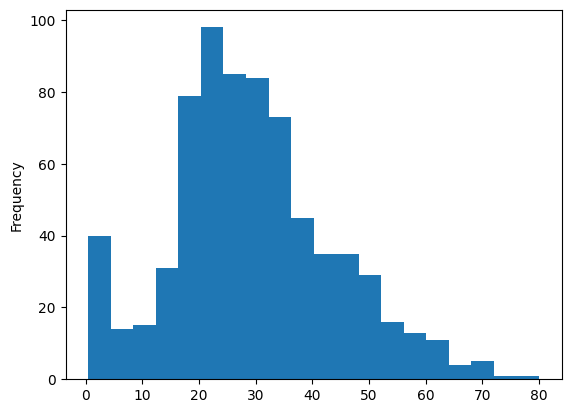

In [6]:
df['Age'].plot(kind='hist',bins=20)

<Axes: ylabel='Density'>

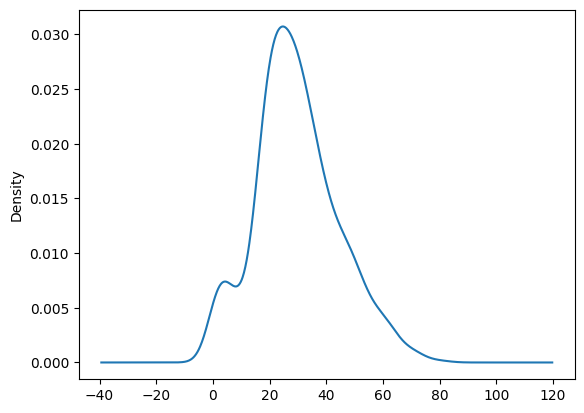

In [7]:
df['Age'].plot(kind='kde') #kernal density estimation 
#Conclusion - Normal Distribution

In [8]:
df['Age'].skew()  #it should be used to calculate the skewness of the data

np.float64(0.38910778230082704)

<Axes: >

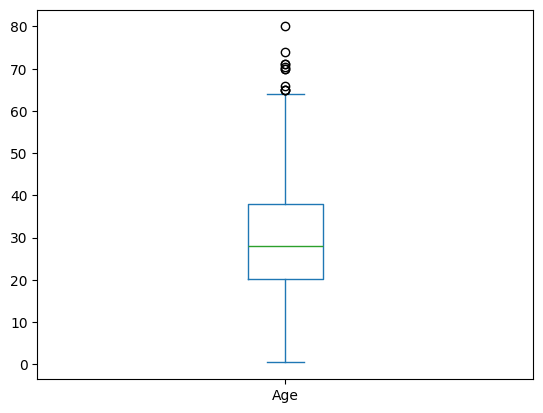

In [9]:
df['Age'].plot(kind='box') 

In [10]:
#checking the outlier which has been generated by the box plot

df[df['Age']>65]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
33,34,0,2,"Wheadon, Mr. Edward H",male,66.0,0,0,C.A. 24579,10.5000,NaN,S
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C
116,117,0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,NaN,Q
493,494,0,1,"Artagaveytia, Mr. Ramon",male,71.0,0,0,PC 17609,49.5042,NaN,C
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0000,A23,S
672,673,0,2,"Mitchell, Mr. Henry Michael",male,70.0,0,0,C.A. 24580,10.5000,NaN,S
745,746,0,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.0000,B22,S
851,852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.7750,NaN,S


In [11]:
#total missing value of the Age column 
df['Age'].isnull().sum()*100/len(df['Age'])


np.float64(19.865319865319865)

### Fare

**conclusions**

- The data is highly(positively) skewed
- Fare col actually contains the group fare and not the individual fare(This migth be and issue)
- We need to create a new col called individual fare

In [12]:
df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

<Axes: ylabel='Frequency'>

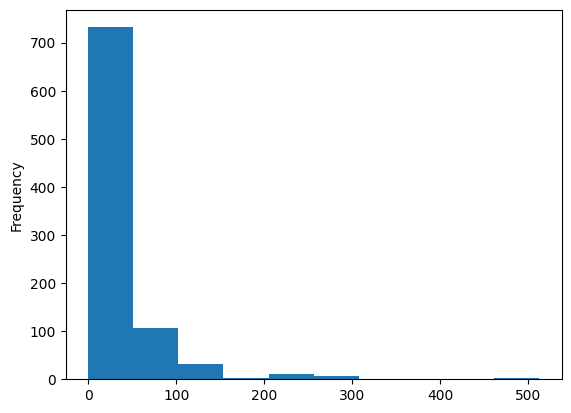

In [13]:
df['Fare'].plot(kind='hist')

<Axes: ylabel='Density'>

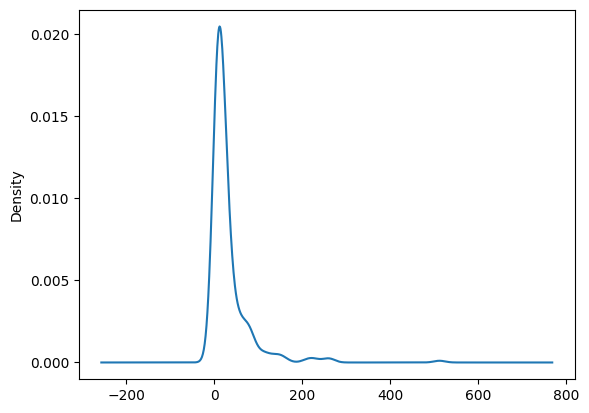

In [14]:
df['Fare'].plot(kind='kde')

In [15]:
df['Fare'].skew() #this is the skewn data

np.float64(4.787316519674893)

<Axes: >

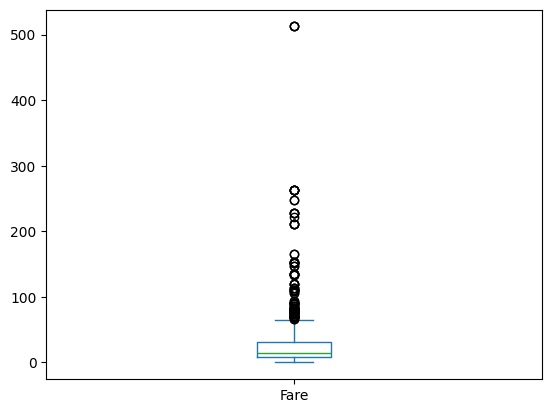

In [16]:
df['Fare'].plot(kind='box')

In [17]:
df[df['Fare']>250]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
311,312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C
341,342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.0000,C23 C25 C27,S
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C
742,743,1,1,"Ryerson, Miss. Susan Parker ""Suzette""",female,21.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C


In [18]:
#because of this outlier we got the information that in a Fare column they had given us the fare of Group not a Individual fare

In [19]:
df['Fare'].isna().sum()

np.int64(0)

### Steps of doing Univariate Analysis on Categorical columns

**Descriptive Statistics**: Compute the frequency distribution of the categories in the column. This will give a general understanding of the distribution of the categories and their relative frequencies.

**Visualizations**: Create visualizations to explore the distribution of the categories. Some common visualizations for categorical data include count plots and pie charts. These visualizations provide a visual representation of the distribution of the categories and can help identify any patterns or anomalies in the data.

**Missing Values**: Check for missing values in the data and decide how to handle them. Missing values can be imputed or excluded from the analysis, depending on the research question and the data set.

**Conclusion**: Summarize the findings of the EDA and make decisions about how to proceed with further analysis.

### Survived

**conclusions**

- Parch and SibSp cols can be merged to form  a new col call family_size
- Create a new col called is_alone

In [20]:
#Descriptive Analysis

df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

<Axes: xlabel='Survived'>

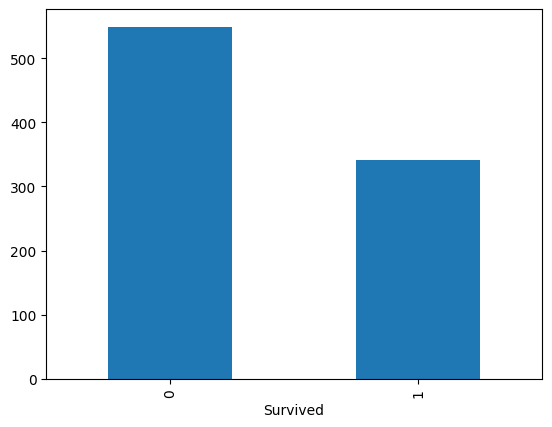

In [21]:
df['Survived'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

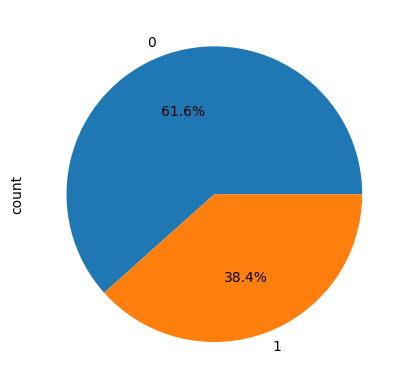

In [22]:
df['Survived'].value_counts().plot(kind='pie',autopct='%0.1f%%')

In [23]:
df['Survived'].isna().sum() #No Missing Value

np.int64(0)

In [24]:
#PClass

df['Pclass'].value_counts()
#maybe some problem here because of the mostly it should be 3 -> 2 -> 1

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

<Axes: xlabel='Pclass'>

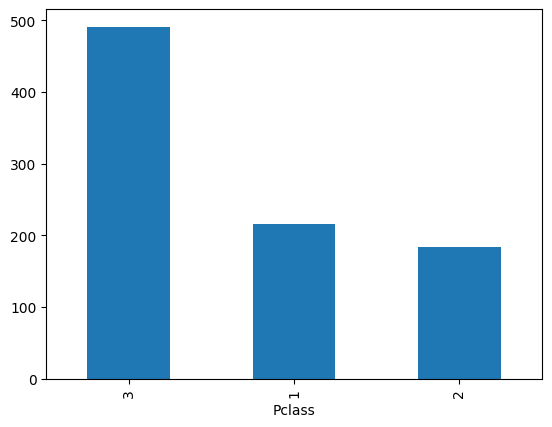

In [25]:
df['Pclass'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

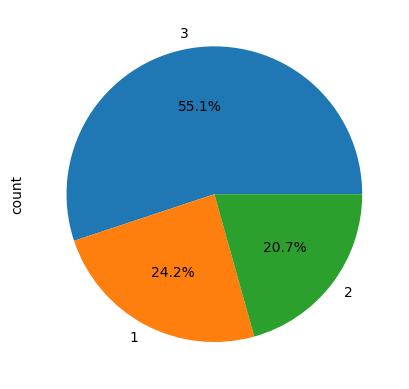

In [26]:
df['Pclass'].value_counts().plot(kind='pie',autopct='%0.1f%%')

In [27]:
#Sex Column

df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

<Axes: xlabel='Sex'>

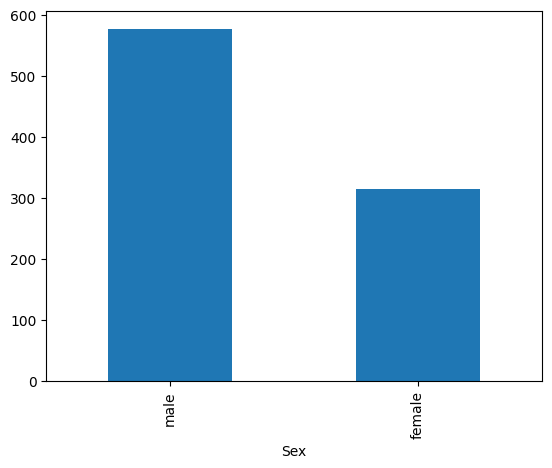

In [28]:
df['Sex'].value_counts().plot(kind='bar')

In [40]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Mixed Category 

We need to convert this column to some usefull form to do this analysis

### Steps of doing Bivariate Analysis

- Select 2 cols
- Understand type of relationship
    1. **Numerical - Numerical**<br>
        a. You can plot graphs like scatterplot(regression plots), 2D histplot, 2D KDEplots<br>
        b. Check correlation coefficent to check linear relationship
    2. **Numerical - Categorical** - create visualizations that compare the distribution of the numerical data across different categories of the categorical data.<br>
        a. You can plot graphs like barplot, boxplot, kdeplot violinplot even scatterplots<br>
    3. **Categorical - Categorical**<br>
        a. You can create cross-tabulations or contingency tables that show the distribution of values in one categorical column, grouped by the values in the other categorical column.<br>
        b. You can plots like heatmap, stacked barplots, treemaps
        
- Write your conclusions
    1. Clearly Pclass 1 People survived more compare to Pclass3

<Axes: xlabel='Pclass', ylabel='Survived'>

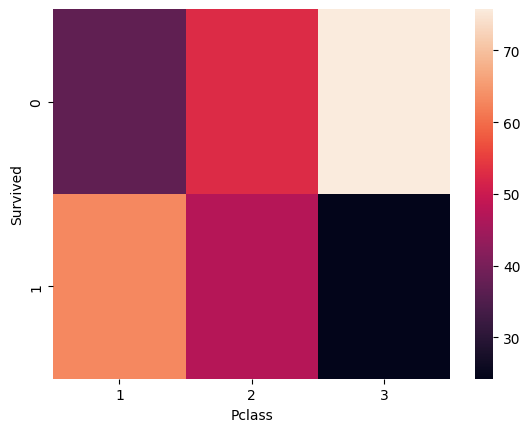

In [39]:
#You need to go step by step

#FInd Most important column and which has most missing value

sns.heatmap(pd.crosstab(df['Survived'],df['Pclass'],normalize='columns')*100)

<Axes: xlabel='Sex', ylabel='Survived'>

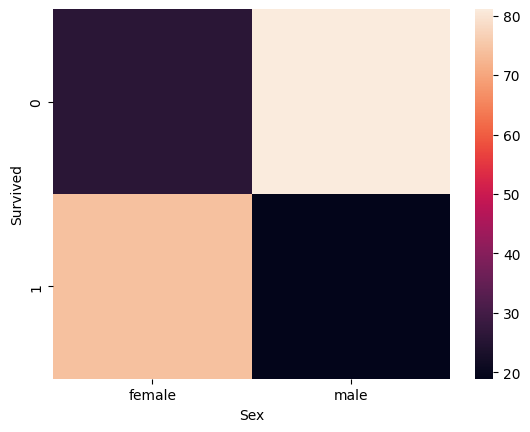

In [41]:
sns.heatmap(pd.crosstab(df['Survived'],df['Sex'],normalize='columns')*100)

<Axes: xlabel='Embarked', ylabel='Survived'>

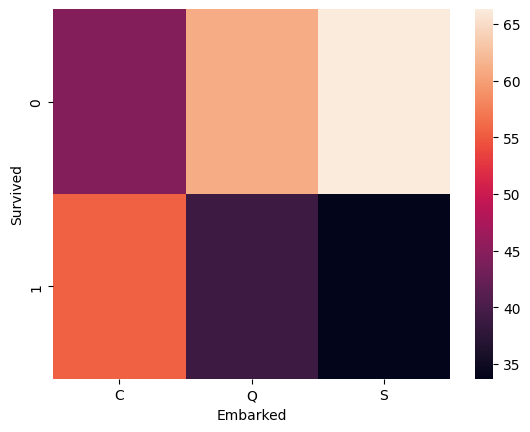

In [42]:
sns.heatmap(pd.crosstab(df['Survived'],df['Embarked'],normalize='columns')*100)

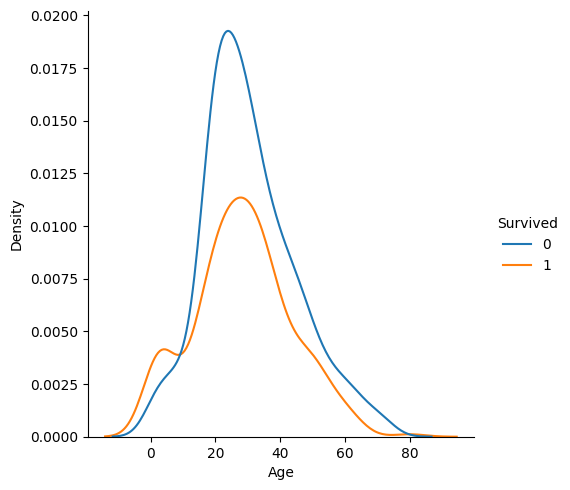

In [45]:
#Survived and Age Relation
#Violin Chart and 

sns.displot(data=df,x='Age',kind='kde',hue='Survived')

In [31]:
# Feature Engineering on Fare col

In [52]:
df1 = pd.read_csv('Data/test.csv')
df2 = pd.concat([df,df1],ignore_index = True)

In [56]:
df2.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1304,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1305,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1306,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
1307,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
1308,1309,NaN,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


In [61]:
individual_fare = df2['Fare']/(df2['SibSp'] + df2['Parch']+1)
df2.insert(10,'Individual_Fare',individual_fare)

In [ ]:
df2.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Individual_Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,3.62500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,35.64165,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,7.92500,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,26.55000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,8.05000,NaN,S


<Axes: xlabel='Individual_Fare'>

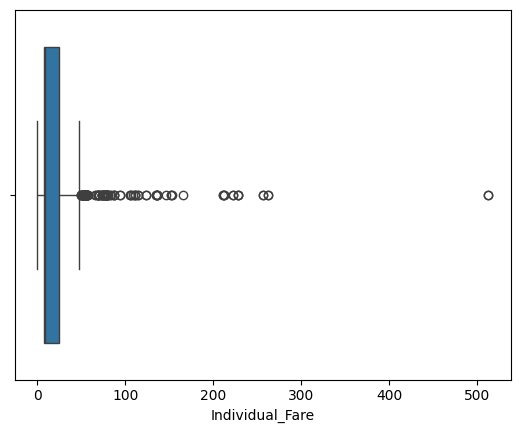

In [66]:
sns.boxplot(data=df2,x='Individual_Fare')

In [69]:
#New Feature related to the Family Size

df2['Family_size'] = df2['SibSp'] + df2['Parch'] + 1

In [71]:
#Family Type
# 1->Alone
# 2-4->Small Family
# >=5 ->Large Family

def transform_family(x):
    if x == 1:
        return 'Alone'
    elif x > 1 and x <=4:
        return 'Small Family'
    elif x > 4:
        return 'Large Family'
    
df2['Family_Type'] = df2['Family_size'].apply(transform_family)

<Axes: xlabel='Family_Type', ylabel='Survived'>

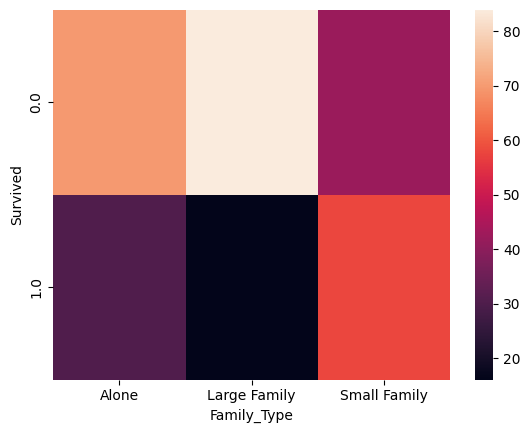

In [74]:
sns.heatmap(pd.crosstab(df2['Survived'],df2['Family_Type'],normalize='columns')*100)

In [78]:
#Name Column

last_name = df2['Name'].str.split(',').str.get(0)
df2.insert(4,'Last_Name',last_name)

In [79]:
df2.head()

,PassengerId,Survived,Pclass,Name,Last_Name,Sex,Age,SibSp,Parch,Ticket,Fare,Individual_Fare,Cabin,Embarked,Family_size,Family_Type
0,1,0.0,3,"Braund, Mr. Owen Harris",Braund,male,22.0,1,0,A/5 21171,7.2500,3.62500,NaN,S,2,Small Family
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Cumings,female,38.0,1,0,PC 17599,71.2833,35.64165,C85,C,2,Small Family
2,3,1.0,3,"Heikkinen, Miss. Laina",Heikkinen,female,26.0,0,0,STON/O2. 3101282,7.9250,7.92500,NaN,S,1,Alone
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Futrelle,female,35.0,1,0,113803,53.1000,26.55000,C123,S,2,Small Family
4,5,0.0,3,"Allen, Mr. William Henry",Allen,male,35.0,0,0,373450,8.0500,8.05000,NaN,S,1,Alone


In [89]:
title = df2['Name'].str.split(',').str.get(1).str.strip().str.split('.').str.get(0)
title  = title.str.replace('Rev','Other')
title  = title.str.replace('Dr','Other')
title  = title.str.replace('Col','Other')
title  = title.str.replace('Major','Other')
title  = title.str.replace('Don','Other')
title  = title.str.replace('Capt','Other')
title  = title.str.replace('the Countess','Other')
title  = title.str.replace('Jonkheer','Other')

In [90]:
title.value_counts()

Name
Mr        757
Miss      260
Mrs       197
Master     61
Other      26
Ms          2
Mlle        2
Mme         1
Lady        1
Sir         1
Othera      1
Name: count, dtype: int64

In [91]:
df2.insert(5,'Title',title)

In [98]:
temp_df = df2[df2['Title'].isin(['Mr','Miss','Mrs','Master','Other'])]

In [99]:
pd.crosstab(temp_df['Survived'],temp_df['Title'],normalize='columns')*100

Title,Master,Miss,Mr,Mrs,Other
Survived,,,,,
0.0,42.5,30.21978,84.332689,20.8,71.428571
1.0,57.5,69.78022,15.667311,79.2,28.571429


In [100]:
pd.crosstab(df2['Survived'],df2['Last_Name'],normalize='columns')*100

Last_Name,Abbing,Abbott,Abelson,Adahl,Adams,Ahlin,Aks,Albimona,Alexander,Alhomaki,...,Yousseff,Yrois,Zabour,Zimmerman,de Messemaeker,de Mulder,de Pelsmaeker,del Carlo,van Billiard,van Melkebeke
Survived,,,,,,,,,,,,,,,,,,,,,
0.0,100.0,50.0,50.0,100.0,100.0,100.0,0.0,0.0,100.0,100.0,...,100.0,100.0,100.0,100.0,0.0,0.0,100.0,100.0,100.0,100.0
1.0,0.0,50.0,50.0,0.0,0.0,0.0,100.0,100.0,0.0,0.0,...,0.0,0.0,0.0,0.0,100.0,100.0,0.0,0.0,0.0,0.0


In [106]:
#Column with a Dec Information

df2['Deck'] = df2['Cabin'].str[0].fillna('M')

In [107]:
df2.head()

,PassengerId,Survived,Pclass,Name,Last_Name,Title,Sex,Age,SibSp,Parch,Ticket,Fare,Individual_Fare,Cabin,Embarked,Family_size,Family_Type,Deck
0,1,0.0,3,"Braund, Mr. Owen Harris",Braund,Mr,male,22.0,1,0,A/5 21171,7.2500,3.62500,NaN,S,2,Small Family,M
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Cumings,Mrs,female,38.0,1,0,PC 17599,71.2833,35.64165,C85,C,2,Small Family,C
2,3,1.0,3,"Heikkinen, Miss. Laina",Heikkinen,Miss,female,26.0,0,0,STON/O2. 3101282,7.9250,7.92500,NaN,S,1,Alone,M
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Futrelle,Mrs,female,35.0,1,0,113803,53.1000,26.55000,C123,S,2,Small Family,C
4,5,0.0,3,"Allen, Mr. William Henry",Allen,Mr,male,35.0,0,0,373450,8.0500,8.05000,NaN,S,1,Alone,M


In [111]:
pd.crosstab(df2['Survived'],df2['Deck'],normalize='columns')*100

Deck,A,B,C,D,E,F,G,M,T
Survived,,,,,,,,,
0.0,53.333333,25.531915,40.677966,24.242424,25.0,38.461538,50.0,70.014556,100.0
1.0,46.666667,74.468085,59.322034,75.757576,75.0,61.538462,50.0,29.985444,0.0


In [ ]:
df.corr()
#this is related to the corelation so if two column is related to eachother then you will ignore that

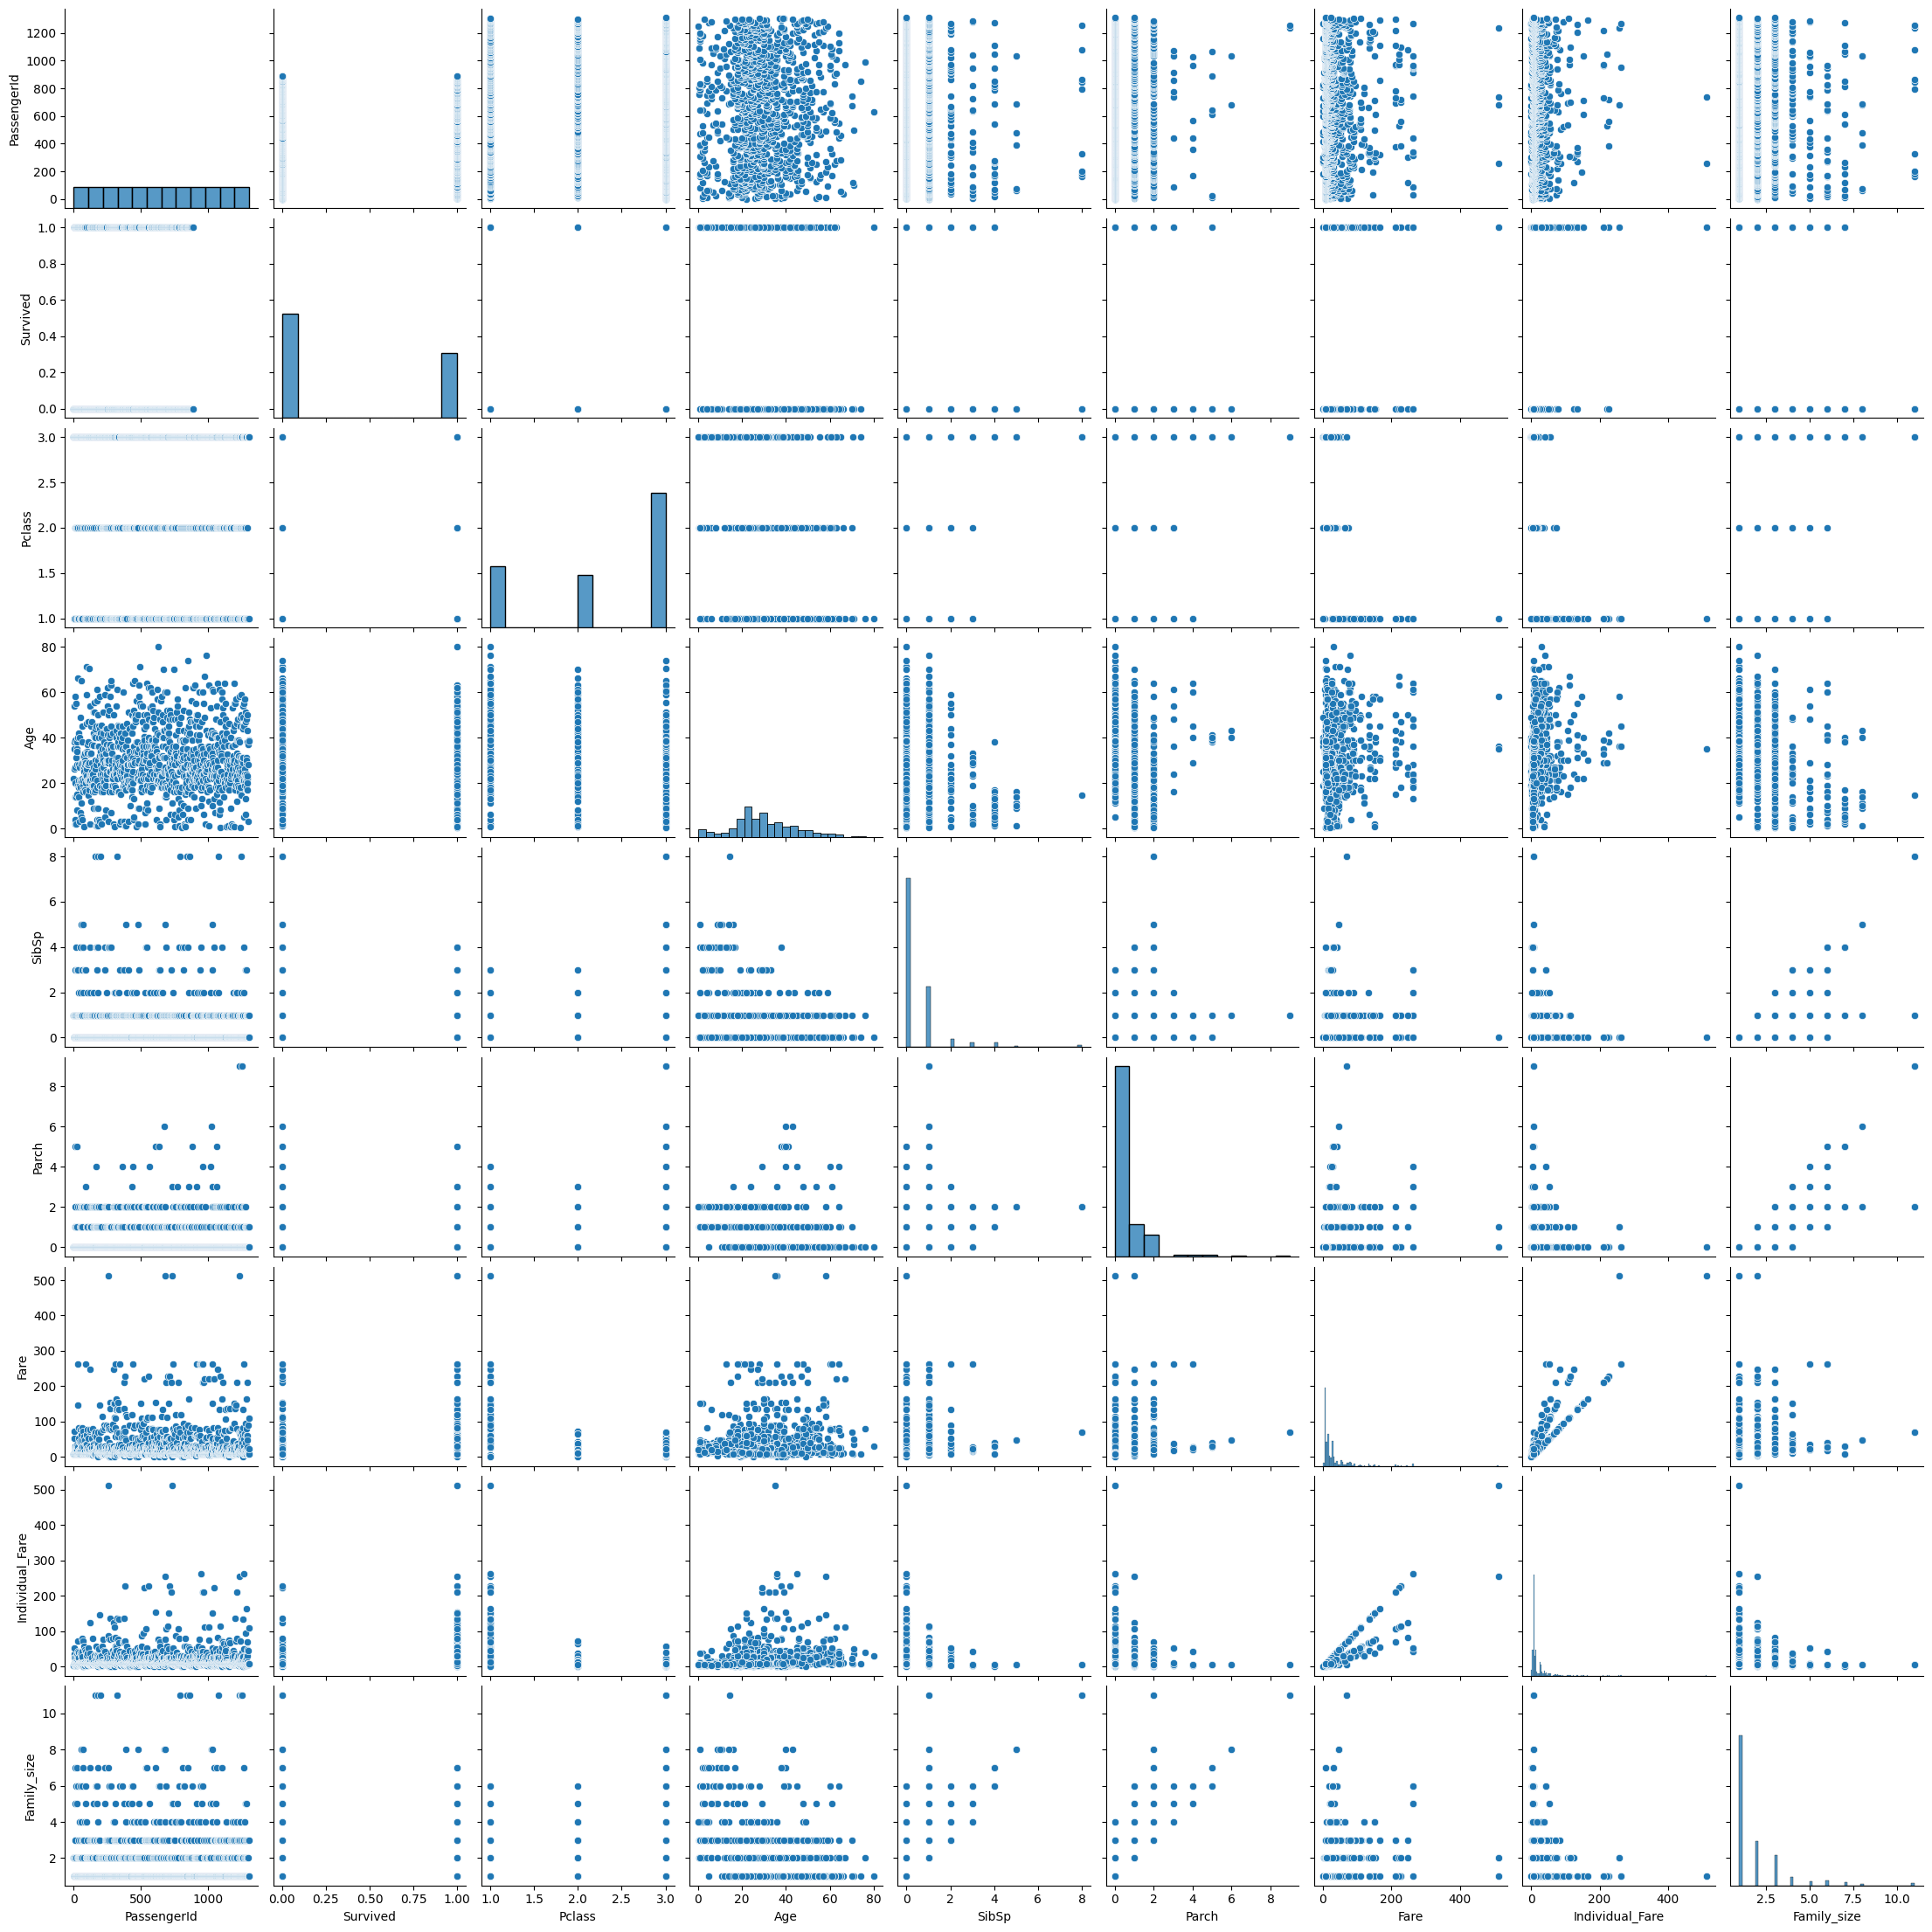

In [114]:
sns.pairplot(df2)